In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
DATA_PATH = Path("../data/assurance-maladie.csv")

df = pd.read_csv(DATA_PATH)

df = df.drop_duplicates()

In [3]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [5]:
best_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                random_state=42,
                learning_rate=0.05,
                max_depth=3,
                n_estimators=300,
                subsample=1.0
            )
        )
    ]
)

In [6]:
best_xgb_pipeline.fit(X_train, y_train)

predictions = best_xgb_pipeline.predict(X_test)

In [7]:
feature_names = best_xgb_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['num__age', 'num__bmi', 'num__children', 'cat__sex_female',
       'cat__sex_male', 'cat__smoker_no', 'cat__smoker_yes',
       'cat__region_northeast', 'cat__region_northwest',
       'cat__region_southeast', 'cat__region_southwest'], dtype=object)

In [8]:
xgb_model = best_xgb_pipeline.named_steps["model"]

importance_scores = xgb_model.feature_importances_

importance_scores

array([0.03162351, 0.03620676, 0.00861074, 0.00454901, 0.        ,
       0.89896923, 0.        , 0.00522151, 0.00688877, 0.00416894,
       0.00376151], dtype=float32)

In [9]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_scores
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
5,cat__smoker_no,0.898969
1,num__bmi,0.036207
0,num__age,0.031624
2,num__children,0.008611
8,cat__region_northwest,0.006889
7,cat__region_northeast,0.005222
3,cat__sex_female,0.004549
9,cat__region_southeast,0.004169
10,cat__region_southwest,0.003762
4,cat__sex_male,0.000000


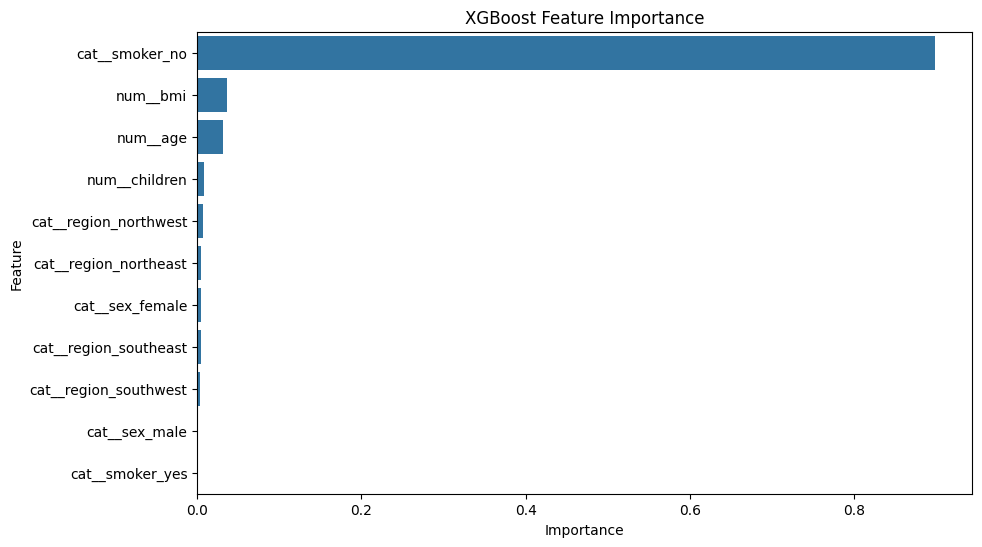

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()

In [11]:
importance_df.head(5)

,Feature,Importance
5,cat__smoker_no,0.898969
1,num__bmi,0.036207
0,num__age,0.031624
2,num__children,0.008611
8,cat__region_northwest,0.006889
